# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../General_Functions/")

from Flow_functions import *

# Define plotting functions

In [19]:
# #118AB2 flow color

from matplotlib.colors import Normalize
def StreamPlot(ax, dx, ux, step, Flow, n, color):
    
    
    x = np.linspace(dx, ux, step)
    z = np.linspace(dx, ux, step)
  
    X,Z = np.meshgrid(x,z)
    
    e = np.array([0, 0, 1])
    
    U = np.zeros((len(x), len(x)))
    W = np.zeros((len(x), len(x)))
   
    for j in range(step):
        for i in range(step):
            Position = np.array([x[i], 0, z[j]])
            # Check if flow is gradient then project
            if Flow(e, Position).shape == (3, 3):
                flow = np.dot(Flow(e, Position), n)
            else:
                flow = Flow(e, Position)
                
            if np.linalg.norm(flow) < 1e-15:
                flow = np.zeros(3)
                
            U[j, i], _, W[j, i]  = flow
            

    stream = ax.streamplot(z, x, U, W, linewidth= 1.5, density = .5, arrowstyle = '->', arrowsize = 2.0, color = color, broken_streamlines=False) 

def StreamPlotNoise(ax, dx, ux, step, Flow, Noise, n, color):
    
    
    x = np.linspace(dx, ux, step)
    z = np.linspace(dx, ux, step)
  
    X,Z = np.meshgrid(x,z)
    
    e = np.array([0, 0, 1])
    
    U = np.zeros((len(x), len(x)))
    W = np.zeros((len(x), len(x)))
   
    for j in range(step):
        for i in range(step):
            Position = np.array([x[i], 0, z[j]])
            # Check if flow is gradient then project
            if Flow(e, Position).shape == (3, 3):
                flow = np.dot(Flow(e, Position), n)
            else:
                flow = Flow(e, Position) + Noise*np.array([0, 0,  z[j]])
                
            if np.linalg.norm(flow) < 1e-15:
                flow = np.zeros(3)
                
            U[j, i], _, W[j, i]  = flow
            

    stream = ax.streamplot(z, x, U, W, linewidth= 5, density = .6, arrowstyle = '->', arrowsize = 3.0, color = color, broken_streamlines=False) 

# #118AB2 flow color

def ContourPlot(ax, dx, ux, step, Flow, n, colormap):
    
    
    x = np.linspace(dx, ux, step)
    z = np.linspace(dx, ux, step)
  
    X,Z = np.meshgrid(x,z)
    
    e = np.array([0, 0, 1])
    
    U = np.zeros((len(x), len(x)))
    W = np.zeros((len(x), len(x)))
   
    for j in range(step):
        for i in range(step):
            Position = np.array([x[i], 0, z[j]])
            # Check if flow is gradient then project
            if Flow(e, Position).shape == (3, 3):
                flow = np.dot(Flow(e, Position), n)
            else:
                flow = Flow(e, Position)
                
            if np.linalg.norm(flow) < 1e-15:
                flow = np.zeros(3)
            if np.linalg.norm(Position) < .1:
                flow = np.zeros(3)  
            U[j, i], _, W[j, i]  = flow
    
    # Create a Normalize object to control the scaling of colors

    contour = ax.contourf(X, Z, np.sqrt(U**2 + W**2), levels=1000, cmap=colormap, vmin=0.0, vmax=np.max(np.sqrt(U**2 + W**2)) )
    #cbar = plt.colorbar(contour, cmap=colormap,fraction=0.046, pad=0.04)
    #cbar.set_ticks([])


def ContourPlotNoise(ax, dx, ux, step, Flow, Noise, n, colormap):
    
    
    x = np.linspace(dx, ux, step)
    z = np.linspace(dx, ux, step)
  
    X,Z = np.meshgrid(x,z)
    
    e = np.array([0, 0, 1])
    
    U = np.zeros((len(x), len(x)))
    W = np.zeros((len(x), len(x)))
   
    for j in range(step):
        for i in range(step):
            Position = np.array([x[i], 0, z[j]])
            # Check if flow is gradient then project
            if Flow(e, Position).shape == (3, 3):
                flow = np.dot(Flow(e, Position), n)
            else:
                flow = Flow(e, Position) + Noise*np.array([0, 0,  z[j]])
                
            if np.linalg.norm(flow) < 1e-15:
                flow = np.zeros(3)
            if np.linalg.norm(Position) < .95:
                flow = np.zeros(3)  
            U[j, i], _, W[j, i]  = flow
    
    # Create a Normalize object to control the scaling of colors
    
    contour = ax.contourf(X, Z, np.sqrt(U**2 + W**2), levels=1000, cmap=colormap, vmin=0.0, vmax=np.max(np.sqrt(U**2 + W**2)) )
    #cbar = plt.colorbar(contour, cmap=colormap,fraction=0.046, pad=0.04)
    #cbar.set_ticks([])

# Plots

<Figure size 400x800 with 0 Axes>

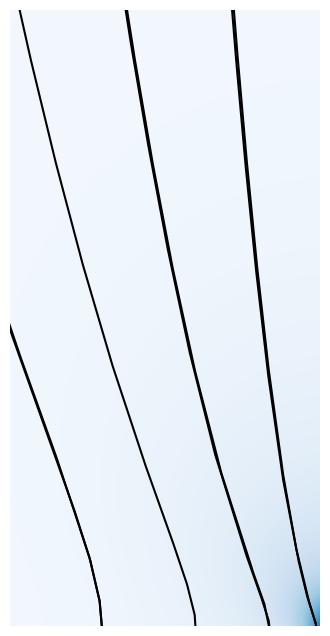

In [22]:
fig = plt.figure(figsize=(4, 8))

n = np.array([0, 0, 1]) # Antennae direction, project gradient along this 
                        # direction before plotting


dx = -5 # Smallest x-axis and y-axis coordinate
ux = 5# Highest  x-axis and y-axis coordinate
Flows = [FlowStokeslet]# FlowStokeslet, FlowStresslet]
FlowName = ['FlowStokeslet']#'FlowStokeslet', 'FlowStresslet']

for grad, Flow in enumerate(Flows):
    fig = plt.figure(figsize=(4, 8))
    ax = fig.add_subplot(111)
    ContourPlot(ax, dx, ux, 256, Flow, n, colormap = 'Blues') 
    StreamPlot(ax, dx, ux, 256, Flow, n, color = 'black') 
    #ax.set_title(GradName[grad])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    #PlotCircles(ax, 1)
    scale = 1
    
    # Uncomment to draw arrows
    #ax.arrow(dx + 3, dx + 3, n[0]*scale, n[2]*scale, color='black', width = .045, head_width = .0, head_length = .0)
    
    # Uncomment to fix axis range
    ax.set_xlim([-2, -0.1])
    ax.set_ylim([0.1, 4.])
    #ax.axis("equal")
    
    # Uncomment to save
    #ax.legend()
    plt.savefig(str(FlowName[grad])+".pdf", bbox_inches='tight')


<Figure size 1000x1000 with 0 Axes>

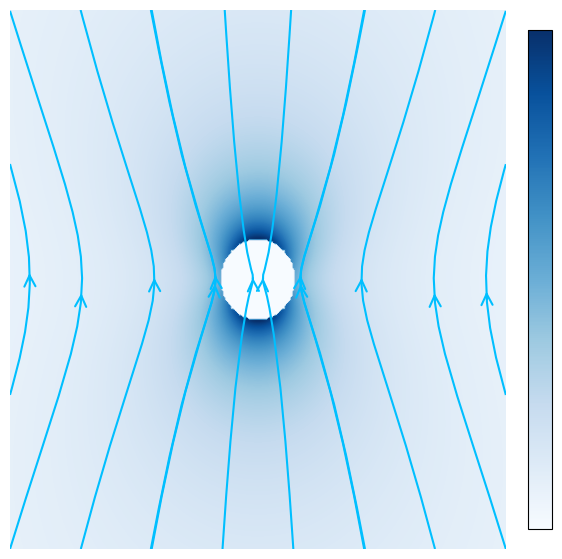

In [4]:
fig = plt.figure(figsize=(10, 10))

n = np.array([0, 0, 1]) # Antennae direction, project gradient along this 
                        # direction before plotting


dx = -5 # Smallest x-axis and y-axis coordinate
ux = 5 # Highest  x-axis and y-axis coordinate
Flows = [FlowStokeslet]# FlowStokeslet, FlowStresslet]
FlowName = ['FlowStokeslet']#'FlowStokeslet', 'FlowStresslet']

for grad, Flow in enumerate(Flows):
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111)
    ContourPlot(ax, dx, ux, 256, Flow, n, colormap='Blues') 
    StreamPlot(ax, dx, ux, 256, Flow, n, color = 'deepskyblue') 
    #ax.set_title(GradName[grad])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    #PlotCircles(ax, 1)
    scale = 1
    
    # Uncomment to draw arrows
    #ax.arrow(dx + 3, dx + 3, n[0]*scale, n[2]*scale, color='black', width = .045, head_width = .0, head_length = .0)
    
    # Uncomment to fix axis range
    #ax.set_xlim([dx, ux])
    #ax.set_ylim([dx, ux])
    #ax.axis("equal")
    
    # Uncomment to save
    #ax.legend()
    plt.savefig(str(FlowName[grad])+".pdf", bbox_inches='tight')


<Figure size 1000x1000 with 0 Axes>

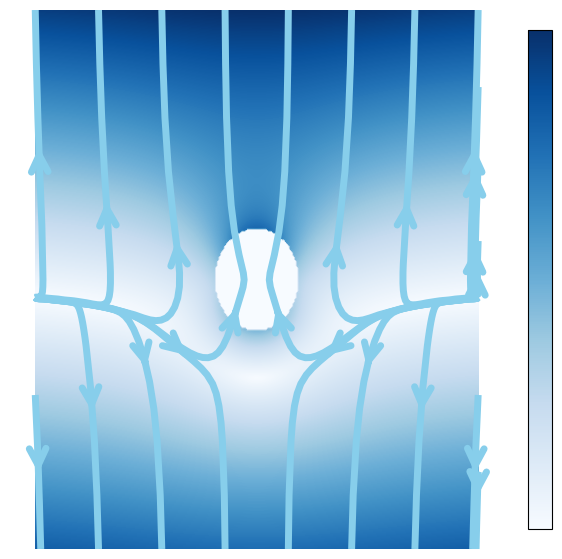

In [31]:
fig = plt.figure(figsize=(10, 10))

n = np.array([0, 0, 1]) # Antennae direction, project gradient along this 
                        # direction before plotting


dx = -5 # Smallest x-axis and y-axis coordinate
ux = 5 # Highest  x-axis and y-axis coordinate
Flows = [FlowStokeslet]# FlowStokeslet, FlowStresslet]
FlowName = ['FlowStokeslet']#'FlowStokeslet', 'FlowStresslet']
Noise = 0.6
for grad, Flow in enumerate(Flows):
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111)
    ContourPlotNoise(ax, dx, ux, 256, Flow, Noise, n, colormap='Blues') 
    StreamPlotNoise(ax, dx, ux, 256, Flow, Noise, n, color = 'skyblue') 
    #ax.set_title(GradName[grad])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    #PlotCircles(ax, 1)
    scale = 1
    
    # Uncomment to draw arrows
    #ax.arrow(dx + 3, dx + 3, n[0]*scale, n[2]*scale, color='black', width = .045, head_width = .0, head_length = .0)
    
    # Uncomment to fix axis range
    #ax.set_xlim([dx, ux])
    #ax.set_ylim([dx, ux])
    #ax.axis("equal")
    
    # Uncomment to save
    #ax.legend()
    plt.savefig(str(FlowName[grad])+"_noise.pdf", bbox_inches='tight')
